**data preprocessing**

In [1]:
import pandas as pd
from urllib.parse import unquote
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
#'legitimate': 0,'phishing': 1

In [2]:
phishstorm = pd.read_csv('/kaggle/input/url-phishing-detection/PhishStorm.csv', encoding='latin1',on_bad_lines='skip')
legitphish = pd.read_csv('/kaggle/input/url-phishing-detection/legitphish.csv')

print("PhishStorm shape:", phishstorm.shape)
print("LegitPhish shape:", legitphish.shape)



PhishStorm shape: (96005, 14)
LegitPhish shape: (101219, 18)


In [3]:
phishstorm.head()

,domain,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,10000000,1.0,0.0,18.0,107.611111,107.277778,0.0,0.0,0.0,0.0,0.8,0.795729,1.0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,10000000,0.0,0.0,11.0,150.636364,152.272727,0.0,0.0,0.0,0.0,0,0.768577,1.0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,10000000,0.0,0.0,14.0,73.500000,72.642857,0.0,0.0,0.0,0.0,0,0.726582,1.0
3,mail.printakid.com/www.online.americanexpress....,10000000,0.0,0.0,6.0,562.000000,590.666667,0.0,0.0,0.0,0.0,0,0.85964,1.0
4,thewhiskeydregs.com/wp-content/themes/widescre...,10000000,0.0,0.0,8.0,29.000000,24.125000,0.0,0.0,0.0,0.0,0,0.748971,1.0


In [4]:
phishstorm.info()
phishstorm.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96005 entries, 0 to 96004
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   domain         96005 non-null  object 
 1   ranking        95953 non-null  object 
 2   mld_res        95935 non-null  object 
 3   mld.ps_res     95924 non-null  object 
 4   card_rem       95923 non-null  float64
 5   ratio_Rrem     95923 non-null  float64
 6   ratio_Arem     95923 non-null  float64
 7   jaccard_RR     95922 non-null  float64
 8   jaccard_RA     95921 non-null  float64
 9   jaccard_AR     95920 non-null  float64
 10  jaccard_AA     95919 non-null  float64
 11  jaccard_ARrd   95919 non-null  object 
 12  jaccard_ARrem  95917 non-null  object 
 13  label          95913 non-null  float64
dtypes: float64(8), object(6)
memory usage: 10.3+ MB


,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,label
count,95923.000000,95923.000000,95923.000000,95922.000000,95921.000000,95920.000000,95919.000000,95913.000000
mean,4.580498,135.255201,138.544211,0.005030,0.003787,0.003378,0.003661,0.499453
std,4.466073,160.988895,175.480485,0.311308,0.024815,0.024011,0.028492,0.500002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,43.000000,39.666667,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,104.000000,103.333333,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,174.142857,178.292857,0.000000,0.000000,0.000000,0.000000,1.000000
max,187.333333,5507.000000,6097.000000,96.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
legitphish.head()

,URL,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,ClassLabel
0,https://keraekken-loagginnusa.godaddysites.com/,47,0,2,1,4.250669,6,1,1,3,1,1,0,1,0,12,0.0,0.0
1,https://metamsk01lgiix.godaddysites.com/,40,0,2,1,4.196439,6,1,1,3,1,0,2,1,0,12,5.0,0.0
2,http://myglobaltech.in/,23,0,1,0,3.936180,5,0,1,2,1,0,0,0,0,12,0.0,0.0
3,http://djtool-for-spotify.com/,30,0,1,0,3.894740,5,0,1,3,1,1,0,1,0,18,0.0,0.0
4,https://scearmcoommunnlty.com/invent/freind/get,47,0,1,1,4.143127,7,0,1,3,18,0,0,1,0,17,0.0,0.0


In [6]:
legitphish.info()
legitphish.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101219 entries, 0 to 101218
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   URL                        101219 non-null  object 
 1   url_length                 101219 non-null  int64  
 2   has_ip_address             101219 non-null  int64  
 3   dot_count                  101219 non-null  int64  
 4   https_flag                 101219 non-null  int64  
 5   url_entropy                101219 non-null  float64
 6   token_count                101219 non-null  int64  
 7   subdomain_count            101219 non-null  int64  
 8   query_param_count          101219 non-null  int64  
 9   tld_length                 101219 non-null  int64  
 10  path_length                101219 non-null  int64  
 11  has_hyphen_in_domain       101219 non-null  int64  
 12  number_of_digits           101219 non-null  int64  
 13  tld_popularity             10

,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,ClassLabel
count,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101219.000000,101218.000000
mean,35.060996,0.484879,3.007775,0.405645,3.976112,6.885733,1.511515,1.010591,5.003270,8.538249,0.042897,8.508669,0.328288,0.146613,6.292218,24.136487,0.370883
std,16.805678,0.499774,0.946612,0.491019,0.307068,1.670271,0.624755,0.202794,2.917429,14.701750,0.202626,8.540811,0.469593,0.353721,5.342714,22.490260,0.483043
min,7.000000,0.000000,0.000000,0.000000,2.521641,1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,0.000000,2.000000,0.000000,3.770942,5.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,31.000000,0.000000,3.000000,0.000000,3.937193,7.000000,2.000000,1.000000,3.000000,2.000000,0.000000,10.000000,0.000000,0.000000,3.000000,19.642857,0.000000
75%,35.000000,1.000000,4.000000,1.000000,4.100817,8.000000,2.000000,1.000000,8.000000,7.000000,0.000000,15.000000,1.000000,0.000000,10.000000,47.058824,1.000000
max,474.000000,1.000000,19.000000,1.000000,5.871503,48.000000,5.000000,14.000000,10.000000,317.000000,1.000000,164.000000,1.000000,1.000000,36.000000,65.957447,1.000000


In [8]:
def clean_normalize(df, url_col='url', label_col='label'):
    df = df.drop_duplicates(subset=[url_col])
    
    df = df.dropna(subset=[url_col, label_col])
    
    df[url_col] = df[url_col].str.encode('utf-8', errors='ignore').str.decode('utf-8')
    
    df[url_col] = df[url_col].str.lower().str.strip()
    df[url_col] = df[url_col].apply(unquote)
    
    df[label_col] = df[label_col].astype(int)
    
    return df

In [9]:
phishstorm.rename(columns={'domain':'url'}, inplace=True)
legitphish.rename(columns={'URL':'url', 'ClassLabel':'label'}, inplace=True)
legitphish['label'] = 1 - legitphish['label']

In [10]:
phishstorm = clean_normalize(phishstorm)
legitphish = clean_normalize(legitphish)

phishstorm.info()
print("\n-------------\n")
phishstorm.describe()



<class 'pandas.core.frame.DataFrame'>
Index: 95911 entries, 0 to 96004
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   url            95911 non-null  object 
 1   ranking        95911 non-null  object 
 2   mld_res        95911 non-null  object 
 3   mld.ps_res     95911 non-null  object 
 4   card_rem       95911 non-null  float64
 5   ratio_Rrem     95911 non-null  float64
 6   ratio_Arem     95911 non-null  float64
 7   jaccard_RR     95911 non-null  float64
 8   jaccard_RA     95911 non-null  float64
 9   jaccard_AR     95911 non-null  float64
 10  jaccard_AA     95911 non-null  float64
 11  jaccard_ARrd   95911 non-null  object 
 12  jaccard_ARrem  95911 non-null  object 
 13  label          95911 non-null  int64  
dtypes: float64(7), int64(1), object(6)
memory usage: 11.0+ MB

-------------



,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,label
count,95911.000000,95911.000000,95911.000000,95911.000000,95911.000000,95911.000000,95911.000000,95911.000000
mean,4.573761,135.262676,138.554597,0.004011,0.003769,0.003368,0.003645,0.499442
std,4.342886,160.993643,175.485738,0.028747,0.024479,0.023795,0.028260,0.500002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,43.000000,39.666667,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,104.076923,103.333333,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,174.142857,178.316666,0.000000,0.000000,0.000000,0.000000,1.000000
max,58.000000,5507.000000,6097.000000,1.000000,0.916667,1.000000,1.000000,1.000000


In [11]:
phishstorm.head()

,url,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,10000000,1.0,0.0,18.0,107.611111,107.277778,0.0,0.0,0.0,0.0,0.8,0.795729,1
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,10000000,0.0,0.0,11.0,150.636364,152.272727,0.0,0.0,0.0,0.0,0,0.768577,1
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,10000000,0.0,0.0,14.0,73.500000,72.642857,0.0,0.0,0.0,0.0,0,0.726582,1
3,mail.printakid.com/www.online.americanexpress....,10000000,0.0,0.0,6.0,562.000000,590.666667,0.0,0.0,0.0,0.0,0,0.85964,1
4,thewhiskeydregs.com/wp-content/themes/widescre...,10000000,0.0,0.0,8.0,29.000000,24.125000,0.0,0.0,0.0,0.0,0,0.748971,1


In [12]:
legitphish.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100872 entries, 0 to 101218
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   url                        100872 non-null  object 
 1   url_length                 100872 non-null  int64  
 2   has_ip_address             100872 non-null  int64  
 3   dot_count                  100872 non-null  int64  
 4   https_flag                 100872 non-null  int64  
 5   url_entropy                100872 non-null  float64
 6   token_count                100872 non-null  int64  
 7   subdomain_count            100872 non-null  int64  
 8   query_param_count          100872 non-null  int64  
 9   tld_length                 100872 non-null  int64  
 10  path_length                100872 non-null  int64  
 11  has_hyphen_in_domain       100872 non-null  int64  
 12  number_of_digits           100872 non-null  int64  
 13  tld_popularity             100872 

In [13]:
legitphish.head()

,url,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,label
0,https://keraekken-loagginnusa.godaddysites.com/,47,0,2,1,4.250669,6,1,1,3,1,1,0,1,0,12,0.0,1
1,https://metamsk01lgiix.godaddysites.com/,40,0,2,1,4.196439,6,1,1,3,1,0,2,1,0,12,5.0,1
2,http://myglobaltech.in/,23,0,1,0,3.936180,5,0,1,2,1,0,0,0,0,12,0.0,1
3,http://djtool-for-spotify.com/,30,0,1,0,3.894740,5,0,1,3,1,1,0,1,0,18,0.0,1
4,https://scearmcoommunnlty.com/invent/freind/get,47,0,1,1,4.143127,7,0,1,3,18,0,0,1,0,17,0.0,1


In [15]:
def scale_features(df, feature_cols):
    scaler = StandardScaler()
    df[feature_cols] = scaler.fit_transform(df[feature_cols])
    return df, scaler

In [16]:
phishstorm_features = ['ranking','mld_res','mld.ps_res','card_rem','ratio_Rrem','ratio_Arem',
                       'jaccard_RR','jaccard_RA','jaccard_AR','jaccard_AA','jaccard_ARrd','jaccard_ARrem']
for col in phishstorm_features:
    phishstorm[col] = pd.to_numeric(phishstorm[col], errors='coerce')
phishstorm = phishstorm.dropna(subset=phishstorm_features)

phishstorm, phishstorm_scaler = scale_features(phishstorm, phishstorm_features)

phishstorm_ml = phishstorm.drop(columns=['url'])   
phishstorm_urls = phishstorm['url']  


In [17]:
legitphish_numeric_features = ['url_length','dot_count','url_entropy','token_count','subdomain_count','query_param_count',
                               'tld_length','path_length','number_of_digits','tld_popularity',
                               'domain_name_length','percentage_numeric_chars']

legitphish_binary_features = ['has_ip_address','https_flag','has_hyphen_in_domain','suspicious_file_extension']

legitphish, legitphish_scaler = scale_features(legitphish, legitphish_numeric_features)
legitphish_ml = legitphish.drop(columns=['url']) 
legitphish_urls = legitphish['url'] 

In [18]:
def split_features_labels(df, feature_cols, label_col='label', test_size=0.2):
    X = df[feature_cols]
    y = df[label_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    return X_train, X_test, y_train, y_test


In [19]:
X_train_ph, X_test_ph, y_train_ph, y_test_ph = split_features_labels(phishstorm, phishstorm_features)

print("PhishStorm Train shape:", X_train_ph.shape)
print("PhishStorm Test shape:", X_test_ph.shape)


PhishStorm Train shape: (76728, 12)
PhishStorm Test shape: (19182, 12)


In [20]:
X_train_lg, X_test_lg, y_train_lg, y_test_lg = split_features_labels(
    legitphish, legitphish_numeric_features + legitphish_binary_features
)

print("LegitPhish Train shape:", X_train_lg.shape)
print("LegitPhish Test shape:", X_test_lg.shape)


LegitPhish Train shape: (80697, 16)
LegitPhish Test shape: (20175, 16)


In [21]:
def apply_smote(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    return X_res, y_res

print("PhishStorm train class distribution:\n", y_train_ph.value_counts())
print("\n\n")
print("LegitPhish train class distribution:\n", y_train_lg.value_counts())
print("\n\n")

X_train_ph_res, y_train_ph_res = apply_smote(X_train_ph, y_train_ph)
X_train_lg_res, y_train_lg_res = apply_smote(X_train_lg, y_train_lg)

print("Resampled PhishStorm Train shape:", X_train_ph_res.shape)
print("\n\n")
print("Resampled LegitPhish Train shape:", X_train_lg_res.shape)

PhishStorm train class distribution:
 label
0    38407
1    38321
Name: count, dtype: int64



LegitPhish train class distribution:
 label
1    50793
0    29904
Name: count, dtype: int64



Resampled PhishStorm Train shape: (76814, 12)



Resampled LegitPhish Train shape: (101586, 16)


In [22]:
webpage = pd.read_csv('/kaggle/input/url-phishing-detection/webpagephishing.csv')
print("webpage shape:", webpage.shape)

webpage shape: (11430, 89)


In [23]:
webpage.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [24]:
webpage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  114

In [25]:
webpage = webpage.drop_duplicates()

print("Missing values per column:\n", webpage.isnull().sum())

webpage = webpage.dropna()

print("Shape after cleaning:", webpage.shape)


Missing values per column:
 url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64
Shape after cleaning: (11430, 89)


In [26]:
webpage = webpage.rename(columns={'status': 'label'})

webpage['label'] = webpage['label'].map({
    'legitimate': 0,
    'phishing': 1
})

print("Label distribution:\n", webpage['label'].value_counts())


Label distribution:
 label
0    5715
1    5715
Name: count, dtype: int64


In [27]:
webpage_urls = webpage['url']

webpage_ml = webpage.drop(columns=['url'])


webpage_features = webpage_ml.drop(columns=['label']).columns

webpage_scaler = StandardScaler()

webpage_ml[webpage_features] = webpage_scaler.fit_transform(webpage_ml[webpage_features])
webpage_ml.head()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974,0
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407,1
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,0.0,2.711505,...,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788,1
3,-0.779940,-0.936306,-0.421020,-0.351010,-0.477984,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,0.537498,-0.885587,-0.28037,-0.528433,-1.307594,-0.375359,-0.143303,-1.070361,-0.073217,0
4,-0.110800,-0.565135,-0.421020,-0.351010,0.480332,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,-1.860473,1.129194,-0.28037,-0.329595,1.323334,-0.424968,-0.143303,-1.070361,1.109355,0


In [28]:

X_train_web, X_test_web, y_train_web, y_test_web = train_test_split(
    webpage_ml.drop(columns=['label']),
    webpage_ml['label'],
    test_size=0.2,
    stratify=webpage_ml['label'],
    random_state=42
)

print("Webpage Train shape:", X_train_web.shape)
print("Webpage Test shape:", X_test_web.shape)

Webpage Train shape: (9144, 87)
Webpage Test shape: (2286, 87)


In [29]:
smote_web = SMOTE(random_state=42)

X_train_web_res, y_train_web_res = smote_web.fit_resample(
    X_train_web,
    y_train_web
)

print("Resampled Webpage Train shape:", X_train_web_res.shape)
print("\n\n")
print("Class distribution after SMOTE:\n", y_train_web_res.value_counts())

Resampled Webpage Train shape: (9144, 87)



Class distribution after SMOTE:
 label
0    4572
1    4572
Name: count, dtype: int64


In [30]:
print("Preprocessed phishstorm dataset shape:", phishstorm_ml.shape)
phishstorm_ml.head()


Preprocessed phishstorm dataset shape: (95910, 13)


,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
0,0.842739,1.093132,-0.503809,3.091549,-0.171751,-0.178225,-0.139512,-0.153969,-0.14153,-0.12897,1.355791,0.451016,1
1,0.842739,-0.914803,-0.503809,1.479717,0.095498,0.078177,-0.139512,-0.153969,-0.14153,-0.12897,-0.847574,0.318078,1
2,0.842739,-0.914803,-0.503809,2.170502,-0.383630,-0.375591,-0.139512,-0.153969,-0.14153,-0.12897,-0.847574,0.112469,1
3,0.842739,-0.914803,-0.503809,0.328409,2.650656,2.576354,-0.139512,-0.153969,-0.14153,-0.12897,-0.847574,0.763927,1
4,0.842739,-0.914803,-0.503809,0.788932,-0.660038,-0.652069,-0.139512,-0.153969,-0.14153,-0.12897,-0.847574,0.222087,1


In [31]:
print("Preprocessed legitphish dataset shape:", legitphish_ml.shape)
legitphish_ml.head()

Preprocessed legitphish dataset shape: (100872, 17)


,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,label
0,0.713242,0,-1.066053,1,0.894567,-0.528552,-0.819846,-0.052315,-0.686015,-0.511691,1,-0.995700,1.431872,0,1.067270,-1.073087,1
1,0.296126,0,-1.066053,1,0.717997,-0.528552,-0.819846,-0.052315,-0.686015,-0.511691,0,-0.761662,1.431872,0,1.067270,-0.850764,1
2,-0.716872,0,-2.123073,0,-0.129392,-1.126903,-2.421059,-0.052315,-1.028770,-0.511691,0,-0.995700,-0.698387,0,1.067270,-1.073087,1
3,-0.299755,0,-2.123073,0,-0.264320,-1.126903,-2.421059,-0.052315,-0.686015,-0.511691,1,-0.995700,1.431872,0,2.189676,-1.073087,1
4,0.713242,0,-2.123073,1,0.544416,0.069799,-2.421059,-0.052315,-0.686015,0.647492,0,-0.995700,1.431872,0,2.002609,-1.073087,1


In [32]:
print("Preprocessed Webpage dataset shape:", webpage_ml.shape)
webpage_ml.head()


Preprocessed Webpage dataset shape: (11430, 88)


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974,0
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407,1
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,0.0,2.711505,...,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788,1
3,-0.779940,-0.936306,-0.421020,-0.351010,-0.477984,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,0.537498,-0.885587,-0.28037,-0.528433,-1.307594,-0.375359,-0.143303,-1.070361,-0.073217,0
4,-0.110800,-0.565135,-0.421020,-0.351010,0.480332,-0.142915,-0.387464,-0.197604,0.0,-0.293683,...,-1.860473,1.129194,-0.28037,-0.329595,1.323334,-0.424968,-0.143303,-1.070361,1.109355,0


**ML modeling**

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import xgboost as xgb
import joblib

In [35]:
rf_ph = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_ph.fit(X_train_ph_res, y_train_ph_res)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [36]:
xgb_ph = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', use_label_encoder=False,
    scale_pos_weight=(len(y_train_ph_res)-sum(y_train_ph_res))/sum(y_train_ph_res)
)
xgb_ph.fit(X_train_ph_res, y_train_ph_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [37]:
rf_lg = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_lg.fit(X_train_lg_res, y_train_lg_res)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [38]:
xgb_lg = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', use_label_encoder=False,
    scale_pos_weight=(len(y_train_lg_res)-sum(y_train_lg_res))/sum(y_train_lg_res)
)
xgb_lg.fit(X_train_lg_res, y_train_lg_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [39]:
rf_wp = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_wp.fit(X_train_web_res, y_train_web_res)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [40]:
xgb_wp = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', use_label_encoder=False,
    scale_pos_weight=(len(y_train_web_res)-sum(y_train_web_res))/sum(y_train_web_res)
)
xgb_wp.fit(X_train_web_res, y_train_web_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [44]:
def evaluate_model(model, X_test, y_test, dataset_name="Dataset"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"{dataset_name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
    print("\n-----------------------------\n")

In [45]:

evaluate_model(rf_ph, X_test_ph, y_test_ph, "Random Forest - PhishStorm")
evaluate_model(xgb_ph, X_test_ph, y_test_ph, "XGBoost - PhishStorm")

evaluate_model(rf_lg, X_test_lg, y_test_lg, "Random Forest - LegitPhish")
evaluate_model(xgb_lg, X_test_lg, y_test_lg, "XGBoost - LegitPhish")

evaluate_model(rf_wp, X_test_web, y_test_web, "Random Forest - Webpage")
evaluate_model(xgb_wp, X_test_web, y_test_web, "XGBoost - Webpage")

Random Forest - PhishStorm
Confusion Matrix:
 [[8675  927]
 [1027 8553]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.90      0.90      9602
           1       0.90      0.89      0.90      9580

    accuracy                           0.90     19182
   macro avg       0.90      0.90      0.90     19182
weighted avg       0.90      0.90      0.90     19182

ROC-AUC Score: 0.9681177568695457

-----------------------------

XGBoost - PhishStorm
Confusion Matrix:
 [[8922  680]
 [ 825 8755]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.92      9602
           1       0.93      0.91      0.92      9580

    accuracy                           0.92     19182
   macro avg       0.92      0.92      0.92     19182
weighted avg       0.92      0.92      0.92     19182

ROC-AUC Score: 0.9796767124890039

-----------------------------

Random Forest - LegitPhi

In [49]:
joblib.dump(rf_ph, 'rf_phishstorm.pkl')

['rf_phishstorm.pkl']

In [50]:

joblib.dump(xgb_ph, 'xgb_phishstorm.pkl')

['xgb_phishstorm.pkl']

In [51]:
joblib.dump(rf_lg, 'rf_legitphish.pkl')

['rf_legitphish.pkl']

In [52]:
joblib.dump(xgb_lg, 'xgb_legitphish.pkl')

['xgb_legitphish.pkl']

In [53]:
joblib.dump(rf_wp, 'rf_webpage.pkl')

['rf_webpage.pkl']

In [54]:
joblib.dump(xgb_wp, 'xgb_webpage.pkl')

['xgb_webpage.pkl']

In [57]:

X_train_ph_mlp = np.array(X_train_ph_res)
X_test_ph_mlp = np.array(X_test_ph)

X_train_lg_mlp = np.array(X_train_lg_res)
X_test_lg_mlp = np.array(X_test_lg)

X_train_wp_mlp = np.array(X_train_web_res)
X_test_wp_mlp = np.array(X_test_web)

y_train_ph_mlp = np.array(y_train_ph_res)
y_test_ph_mlp = np.array(y_test_ph)

y_train_lg_mlp = np.array(y_train_lg_res)
y_test_lg_mlp = np.array(y_test_lg)

y_train_wp_mlp = np.array(y_train_web_res)
y_test_wp_mlp = np.array(y_test_web)

**MLP**

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [61]:
def create_mlp(input_dim, hidden_layers=[64, 32], dropout_rate=0.2):
    """
    input_dim: number of features
    hidden_layers: list of neurons in each hidden layer
    dropout_rate: dropout to prevent overfitting
    """
    model = Sequential()
    
    model.add(Dense(hidden_layers[0], input_dim=input_dim, activation='relu'))
    model.add(Dropout(dropout_rate))
    
    for neurons in hidden_layers[1:]:
        model.add(Dense(neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

In [66]:
mlp_ph = create_mlp(input_dim=X_train_ph_mlp.shape[1])

mlp_lg = create_mlp(input_dim=X_train_lg_mlp.shape[1])

mlp_wp = create_mlp(input_dim=X_train_wp_mlp.shape[1])

In [67]:
# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [68]:
history_ph = mlp_ph.fit(
    X_train_ph_mlp, y_train_ph_mlp,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8085 - loss: 0.4176 - val_accuracy: 0.8467 - val_loss: 0.3493
Epoch 2/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8374 - loss: 0.3613 - val_accuracy: 0.8493 - val_loss: 0.3394
Epoch 3/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8417 - loss: 0.3504 - val_accuracy: 0.8475 - val_loss: 0.3313
Epoch 4/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8476 - loss: 0.3394 - val_accuracy: 0.8599 - val_loss: 0.3212
Epoch 5/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8483 - loss: 0.3333 - val_accuracy: 0.8689 - val_loss: 0.3138
Epoch 6/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8552 - loss: 0.3293 - val_accuracy: 0.8704 - val_loss: 0.3055
Epoch 7/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8584 - loss: 0.3210 - val_accuracy: 0.8741 - val_loss: 0.2996
Epoch 8/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8635 - loss: 0.3129 - 

In [69]:
history_lg = mlp_lg.fit(
    X_train_lg_mlp, y_train_lg_mlp,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9775 - loss: 0.0689 - val_accuracy: 0.9983 - val_loss: 0.0047
Epoch 2/50
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9980 - loss: 0.0058 - val_accuracy: 0.9987 - val_loss: 0.0045
Epoch 3/50
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9984 - loss: 0.0045 - val_accuracy: 0.9998 - val_loss: 0.0025
Epoch 4/50
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9985 - loss: 0.0046 - val_accuracy: 0.9984 - val_loss: 0.0054
Epoch 5/50
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9986 - loss: 0.0039 - val_accuracy: 0.9993 - val_loss: 0.0027
Epoch 6/50
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9989 - loss: 0.0038 - val_accuracy: 0.9996 - val_loss: 0.0016
Epoch 7/50
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9990 - loss: 0.0034 - val_accuracy: 0.9995 - val_loss: 0.0020
Epoch 8/50
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9989 - loss: 0.0034 - 

In [70]:
history_wp = mlp_wp.fit(
    X_train_wp_mlp, y_train_wp_mlp,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7887 - loss: 0.4419 - val_accuracy: 0.9519 - val_loss: 0.1442
Epoch 2/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9375 - loss: 0.1675 - val_accuracy: 0.9524 - val_loss: 0.1298
Epoch 3/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9492 - loss: 0.1488 - val_accuracy: 0.9579 - val_loss: 0.1247
Epoch 4/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9555 - loss: 0.1328 - val_accuracy: 0.9617 - val_loss: 0.1226
Epoch 5/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9576 - loss: 0.1240 - val_accuracy: 0.9639 - val_loss: 0.1179
Epoch 6/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9604 - loss: 0.1092 - val_accuracy: 0.9634 - val_loss: 0.1206
Epoch 7/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9579 - loss: 0.1162 - val_accuracy: 0.9623 - val_loss: 0.1207
Epoch 8/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9623 - loss: 0.1017 - val_accuracy: 0.

In [71]:
def plot_history(history, title="MLP Training"):
    plt.figure(figsize=(8,5))
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

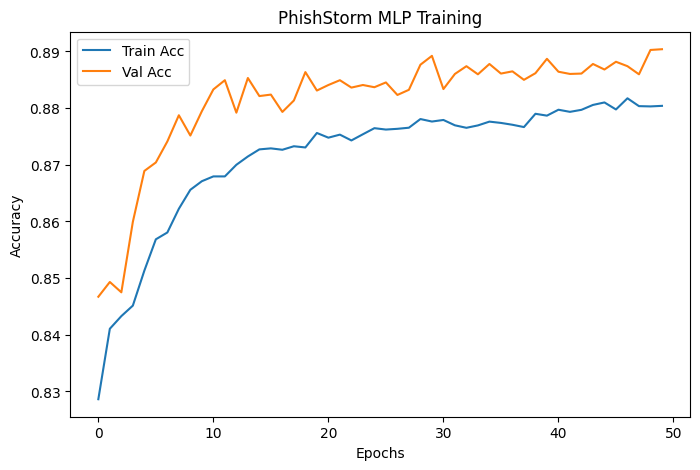

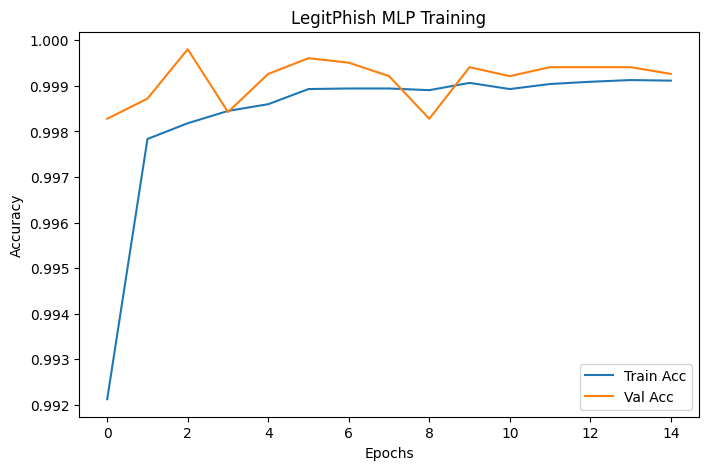

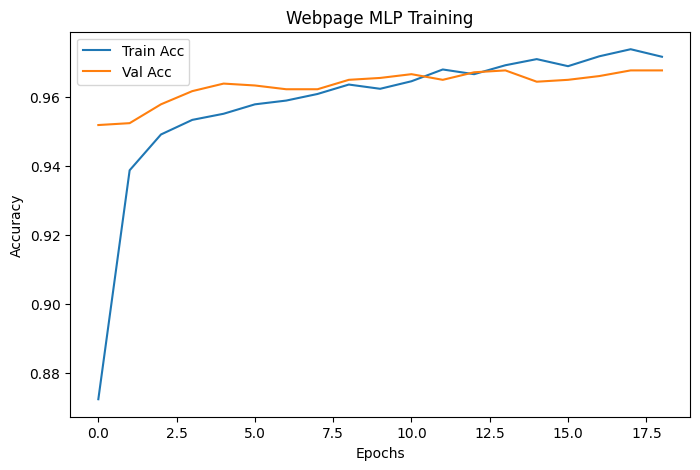

In [72]:
plot_history(history_ph, "PhishStorm MLP Training")

plot_history(history_lg, "LegitPhish MLP Training")

plot_history(history_wp, "Webpage MLP Training")

In [73]:
def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nROC-AUC:", roc_auc_score(y_test, y_pred_prob))
    
    # Plot ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.3f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()


600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step
Confusion Matrix:
 [[8713  889]
 [1281 8299]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89      9602
           1       0.90      0.87      0.88      9580

    accuracy                           0.89     19182
   macro avg       0.89      0.89      0.89     19182
weighted avg       0.89      0.89      0.89     19182


ROC-AUC: 0.9582991800159936


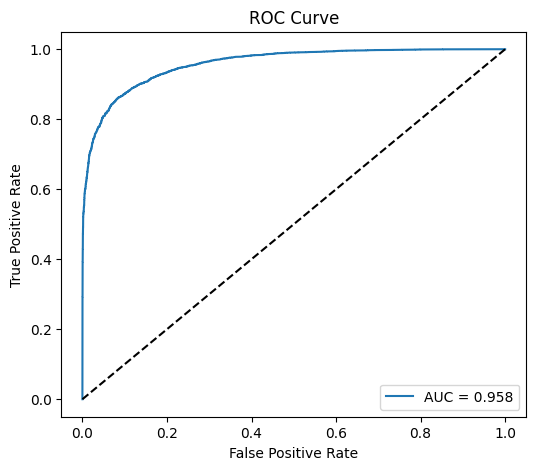

In [75]:
evaluate_model(mlp_ph, X_test_ph_mlp, y_test_ph_mlp)

631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step
Confusion Matrix:
 [[ 7470     6]
 [   12 12687]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      7476
           1       1.00      1.00      1.00     12699

    accuracy                           1.00     20175
   macro avg       1.00      1.00      1.00     20175
weighted avg       1.00      1.00      1.00     20175


ROC-AUC: 0.9999865174774992


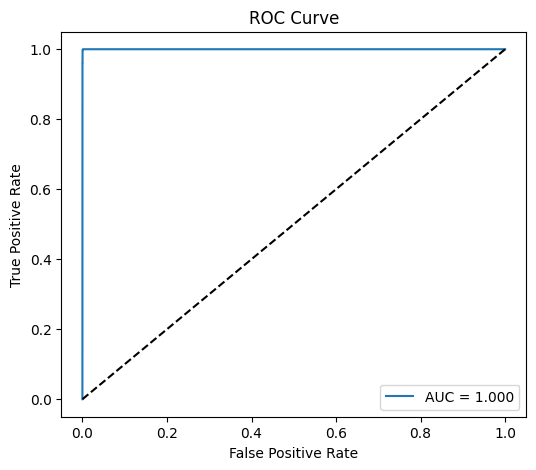

In [76]:
evaluate_model(mlp_lg, X_test_lg_mlp, y_test_lg_mlp)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step
Confusion Matrix:
 [[1096   47]
 [  56 1087]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96      1143
           1       0.96      0.95      0.95      1143

    accuracy                           0.95      2286
   macro avg       0.95      0.95      0.95      2286
weighted avg       0.95      0.95      0.95      2286


ROC-AUC: 0.9897937079824777


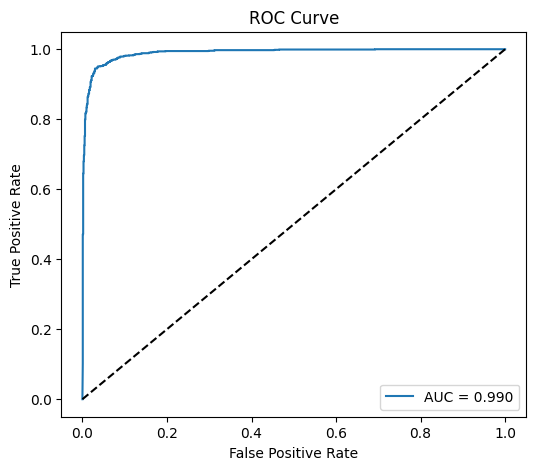

In [77]:
evaluate_model(mlp_wp, X_test_wp_mlp, y_test_wp_mlp)

In [79]:
mlp_ph.save("mlp_phishstorm.h5")
mlp_lg.save("mlp_legitphish.h5")
mlp_wp.save("mlp_webpage.h5")

**DL modeling**